# Stage 3: PPO Reinforcement Learning

**Hyperparams da fix:**
- K=1 (giam tu 2): tranh overfit moi batch
- LR=5e-6 (giam tu 1e-5): update nhe hon
- C2_ENTROPY=0.05 (tang tu 0.01): chong entropy collapse
- C3_KL=0.3 (tang tu 0.1): bam reference manh hon
- EPOCHS=3 (tang tu 2): bu lai K nho hon
- Reward None=0.0 (tu 0.1): khong khuyen khich predict None

In [1]:
!pip install -q torchao --upgrade
!pip install -q --upgrade transformers peft accelerate sentencepiece
!pip install -q torch pyvi pandas matplotlib scikit-learn

In [2]:
import json, os, random
from pathlib import Path

import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt
from pyvi import ViTokenizer
from sklearn.metrics import classification_report, f1_score
from torch import nn
from torch.optim import AdamW
from torch.utils.data import DataLoader, Dataset
from transformers import AutoModel, AutoTokenizer, get_linear_schedule_with_warmup
from peft import LoraConfig, get_peft_model

os.environ["TOKENIZERS_PARALLELISM"] = "false"

In [3]:
import torch.nn.functional as F
from torch.distributions import Categorical

In [4]:
SEED = 42
MODEL_NAME = "vinai/phobert-base"
MAX_LEN = 256
BATCH_SIZE = 16
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

ASPECT_COLS = [
    "FACILITIES#CLEANLINESS","FACILITIES#COMFORT","FACILITIES#DESIGN&FEATURES","FACILITIES#GENERAL",
    "FACILITIES#MISCELLANEOUS","FACILITIES#PRICES","FACILITIES#QUALITY","FOOD&DRINKS#MISCELLANEOUS",
    "FOOD&DRINKS#PRICES","FOOD&DRINKS#QUALITY","FOOD&DRINKS#STYLE&OPTIONS","HOTEL#CLEANLINESS",
    "HOTEL#COMFORT","HOTEL#DESIGN&FEATURES","HOTEL#GENERAL","HOTEL#MISCELLANEOUS","HOTEL#PRICES",
    "HOTEL#QUALITY","LOCATION#GENERAL","ROOMS#CLEANLINESS","ROOMS#COMFORT","ROOMS#DESIGN&FEATURES",
    "ROOMS#GENERAL","ROOMS#MISCELLANEOUS","ROOMS#PRICES","ROOMS#QUALITY","ROOM_AMENITIES#CLEANLINESS",
    "ROOM_AMENITIES#COMFORT","ROOM_AMENITIES#DESIGN&FEATURES","ROOM_AMENITIES#GENERAL",
    "ROOM_AMENITIES#MISCELLANEOUS","ROOM_AMENITIES#PRICES","ROOM_AMENITIES#QUALITY","SERVICE#GENERAL",
]
LABEL_NAMES = ["None", "Positive", "Negative", "Neutral"]
N_POLARITIES = len(LABEL_NAMES)
N_ASPECTS    = len(ASPECT_COLS)

def set_seed(seed=SEED):
    random.seed(seed); np.random.seed(seed); torch.manual_seed(seed)
    if torch.cuda.is_available(): torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

set_seed()
print(f"Device: {DEVICE}")

Device: cuda


In [5]:
from google.colab import drive
drive.mount("/content/drive")

DATA_DIR  = Path("/content/drive/MyDrive/task2_dataset")
SAVE_PATH = Path("/content/drive/MyDrive/ABSA_Task2")
SAVE_PATH.mkdir(parents=True, exist_ok=True)
print(f"DATA_DIR : {DATA_DIR}")
print(f"SAVE_PATH: {SAVE_PATH}")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
DATA_DIR : /content/drive/MyDrive/task2_dataset
SAVE_PATH: /content/drive/MyDrive/ABSA_Task2


In [6]:
# LoRA r=16 target query+key+value (capacity lon hon r=8/qv) - bat buoc giong nhau
# giua Stage 1, 2, 3 vi checkpoint phai compatible.
LORA_R           = 16
LORA_ALPHA       = 32
LORA_TARGETS     = ["query", "key", "value"]
LORA_DROPOUT     = 0.1
HEAD_DROPOUT     = 0.2

def build_lora_backbone():
    phobert = AutoModel.from_pretrained(MODEL_NAME)
    return get_peft_model(phobert, LoraConfig(
        r=LORA_R, lora_alpha=LORA_ALPHA, target_modules=LORA_TARGETS,
        lora_dropout=LORA_DROPOUT, bias="none"))

class PhoBertACSA_LoRA(nn.Module):
    def __init__(self):
        super().__init__()
        self.phobert    = build_lora_backbone()
        self.dropout    = nn.Dropout(HEAD_DROPOUT)
        self.classifier = nn.Linear(self.phobert.config.hidden_size, N_ASPECTS * N_POLARITIES)
    def forward(self, input_ids, attention_mask):
        out = self.phobert(input_ids=input_ids, attention_mask=attention_mask)
        pooled = self.dropout(out.last_hidden_state[:, 0, :])
        return self.classifier(pooled).view(-1, N_ASPECTS, N_POLARITIES)

class PhoBertACSA_ActorCritic(nn.Module):
    def __init__(self):
        super().__init__()
        self.phobert    = build_lora_backbone()
        self.dropout    = nn.Dropout(HEAD_DROPOUT)
        self.classifier = nn.Linear(self.phobert.config.hidden_size, N_ASPECTS * N_POLARITIES)
        self.critic     = nn.Linear(self.phobert.config.hidden_size, N_ASPECTS)
    def forward(self, input_ids, attention_mask):
        out = self.phobert(input_ids=input_ids, attention_mask=attention_mask)
        pooled = self.dropout(out.last_hidden_state[:, 0, :])
        logits = self.classifier(pooled).view(-1, N_ASPECTS, N_POLARITIES)
        values = self.critic(pooled)
        return logits, values

In [7]:
def compute_step_rewards(actions, labels):
    r = torch.full(labels.shape, -1.0, device=labels.device)
    ok = actions == labels
    r[ok & ((labels==2)|(labels==3))] = 2.0   # Negative, Neutral
    r[ok & (labels==1)] = 1.0                  # Positive
    r[ok & (labels==0)] = 0.0                  # None - khong reward
    return r

In [8]:
class ABSADataset(Dataset):
    def __init__(self, df, tokenizer):
        texts = df["Review"].fillna("").astype(str).tolist()
        tokenized = [ViTokenizer.tokenize(t.lower()) for t in texts]
        self.encodings = tokenizer(tokenized, truncation=True, add_special_tokens=True,
                                   max_length=MAX_LEN, padding="max_length")
        self.labels = df[ASPECT_COLS].astype("int64").to_numpy()
    def __len__(self): return len(self.labels)
    def __getitem__(self, i):
        item = {k: torch.tensor(v[i], dtype=torch.long) for k, v in self.encodings.items()}
        item["labels"] = torch.tensor(self.labels[i], dtype=torch.long)
        return item

def make_loader(df, tokenizer, shuffle=False):
    return DataLoader(ABSADataset(df, tokenizer), batch_size=BATCH_SIZE,
                      shuffle=shuffle, num_workers=0, pin_memory=True)

def compute_metrics(y_true, y_pred):
    ft, fp = y_true.reshape(-1), y_pred.reshape(-1)
    m = {
        "flat_macro_f1": f1_score(ft, fp, labels=list(range(N_POLARITIES)), average="macro", zero_division=0),
        "exact_match":   float(np.mean(np.all(y_true == y_pred, axis=1))),
    }
    mask = ft != 0
    m["non_none_macro_f1"]   = f1_score(ft[mask], fp[mask], labels=[1,2,3], average="macro", zero_division=0) if mask.any() else 0.0
    m["per_aspect_macro_f1"] = float(np.mean([
        f1_score(y_true[:,a], y_pred[:,a], labels=list(range(N_POLARITIES)), average="macro", zero_division=0)
        for a in range(y_true.shape[1])]))
    return m

@torch.no_grad()
def evaluate_model(model, loader, criterion=None):
    model.eval()
    all_labels, all_preds, total_loss = [], [], 0.0
    for batch in loader:
        ids    = batch["input_ids"].to(DEVICE)
        mask   = batch["attention_mask"].to(DEVICE)
        labels = batch["labels"].to(DEVICE)
        out    = model(ids, mask)
        logits = out[0] if isinstance(out, tuple) else out
        if criterion:
            total_loss += criterion(logits.reshape(-1, N_POLARITIES), labels.reshape(-1)).item()
        all_labels.append(labels.cpu().numpy())
        all_preds.append(logits.argmax(-1).cpu().numpy())
    y_true = np.concatenate(all_labels)
    y_pred = np.concatenate(all_preds)
    m = compute_metrics(y_true, y_pred)
    if criterion:
        m["loss"] = total_loss / max(len(loader), 1)
    m["y_true"] = y_true; m["y_pred"] = y_pred
    return m

def print_metrics(prefix, m):
    keys = ["loss","flat_macro_f1","non_none_macro_f1","per_aspect_macro_f1","exact_match"]
    parts = [f"{k}: {m[k]:.4f}" for k in keys if k in m]
    print(f"{prefix} | " + " | ".join(parts))

def sample_actions(logits):
    dist = Categorical(logits=logits)
    a = dist.sample()
    return a, dist.log_prob(a)

def kl_divergence(logits, ref_logits):
    lp = F.log_softmax(logits,     dim=-1)
    lq = F.log_softmax(ref_logits, dim=-1)
    return (lp.exp() * (lp - lq)).sum(dim=-1)

In [9]:
tokenizer    = AutoTokenizer.from_pretrained(MODEL_NAME)
train_df     = pd.read_csv(DATA_DIR / "1-VLSP2018-SA-Hotel-train.csv")
dev_df       = pd.read_csv(DATA_DIR / "2-VLSP2018-SA-Hotel-dev.csv")
test_df      = pd.read_csv(DATA_DIR / "3-VLSP2018-SA-Hotel-test.csv")
train_loader = make_loader(train_df, tokenizer, shuffle=True)
dev_loader   = make_loader(dev_df,   tokenizer)
test_loader  = make_loader(test_df,  tokenizer)
print(f"train {len(train_df)} | dev {len(dev_df)} | test {len(test_df)}")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


train 3000 | dev 2000 | test 600


In [10]:
EPOCHS_PPO     = 3
PPO_EPOCHS_K   = 1
LR             = 5e-6
CLIP_EPSILON   = 0.2
C1_VALUE       = 0.5
C2_ENTROPY     = 0.05
C3_KL          = 0.3
ALPHA_REWARD   = 0.7
EVAL_EVERY     = 100

pretrained_ckpt = SAVE_PATH / "actor_critic_pretrained.bin"
if not pretrained_ckpt.exists():
    raise FileNotFoundError(f"Chua co Stage 2 checkpoint: {pretrained_ckpt}")

model = PhoBertACSA_ActorCritic().to(DEVICE)
model.load_state_dict(torch.load(pretrained_ckpt, map_location=DEVICE))

model_ref = PhoBertACSA_ActorCritic().to(DEVICE)
model_ref.load_state_dict(torch.load(pretrained_ckpt, map_location=DEVICE))
model_ref.eval()
for p in model_ref.parameters(): p.requires_grad = False

trainable = [p for p in model.parameters() if p.requires_grad]
print(f"Trainable PPO params: {sum(p.numel() for p in trainable):,}")
optimizer = AdamW(trainable, lr=LR)
total_steps = len(train_loader) * EPOCHS_PPO * PPO_EPOCHS_K
scheduler = get_linear_schedule_with_warmup(
    optimizer,
    num_warmup_steps=max(1, int(0.06 * total_steps)),
    num_training_steps=total_steps)

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] RobertaModel LOAD REPORT from: vinai/phobert-base
Key                       | Status     |  | 
--------------------------+------------+--+-
lm_head.dense.bias        | UNEXPECTED |  | 
lm_head.bias              | UNEXPECTED |  | 
lm_head.decoder.weight    | UNEXPECTED |  | 
lm_head.dense.weight      | UNEXPECTED |  | 
lm_head.decoder.bias      | UNEXPECTED |  | 
lm_head.layer_norm.weight | UNEXPECTED |  | 
lm_head.layer_norm.bias   | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] RobertaModel LOAD REPORT from: vinai/phobert-base
Key                       | Status     |  | 
--------------------------+------------+--+-
lm_head.dense.bias        | UNEXPECTED |  | 
lm_head.bias              | UNEXPECTED |  | 
lm_head.decoder.weight    | UNEXPECTED |  | 
lm_head.dense.weight      | UNEXPECTED |  | 
lm_head.decoder.bias      | UNEXPECTED |  | 
lm_head.layer_norm.weight | UNEXPECTED |  | 
lm_head.layer_norm.bias   | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Trainable PPO params: 1,015,466


In [11]:
history, best_f1, global_step = [], -1.0, 0
final_ckpt = SAVE_PATH / "final_ppo_model.bin"
# Save initial best = SFT performance (lay tu Stage 1) de PPO chi save khi vuot SFT
init_metrics = evaluate_model(model, dev_loader)
best_f1 = init_metrics["non_none_macro_f1"]
torch.save(model.state_dict(), final_ckpt)
print_metrics(f"PPO init (= Stage 2)", init_metrics)
print(f"Baseline non_none_f1: {best_f1:.4f} - PPO chi save khi vuot moc nay")

for epoch in range(1, EPOCHS_PPO + 1):
    print(f"\n=== PPO epoch {epoch}/{EPOCHS_PPO} ===")
    for step, batch in enumerate(train_loader):
        ids    = batch["input_ids"].to(DEVICE)
        mask   = batch["attention_mask"].to(DEVICE)
        labels = batch["labels"].to(DEVICE)

        # Rollout
        model.eval()
        with torch.no_grad():
            logits_old, values_old = model(ids, mask)
            logits_ref, _          = model_ref(ids, mask)
            actions, log_probs_old = sample_actions(logits_old)
            step_rew = compute_step_rewards(actions, labels)
            batch_f1 = f1_score(labels.cpu().numpy().reshape(-1),
                                 actions.cpu().numpy().reshape(-1),
                                 labels=list(range(N_POLARITIES)), average="macro", zero_division=0)
            total_rew = ALPHA_REWARD * step_rew + (1 - ALPHA_REWARD) * batch_f1
            adv = total_rew - values_old
            adv = (adv - adv.mean()) / (adv.std(unbiased=False) + 1e-8)

        # Update K lan
        sums = dict(loss=0., policy=0., value=0., entropy=0., kl=0.)
        for _ in range(PPO_EPOCHS_K):
            model.train()
            optimizer.zero_grad(set_to_none=True)
            logits_new, values_new = model(ids, mask)
            dist_new = Categorical(logits=logits_new)
            log_probs_new = dist_new.log_prob(actions)
            ratio  = torch.exp((log_probs_new - log_probs_old).clamp(-20, 20))
            surr   = torch.min(ratio * adv, torch.clamp(ratio, 1-CLIP_EPSILON, 1+CLIP_EPSILON) * adv)
            p_loss = -surr.mean()
            v_loss = F.mse_loss(values_new, total_rew)
            ent    = dist_new.entropy().mean()
            kl     = kl_divergence(logits_new, logits_ref).mean()
            loss   = p_loss + C1_VALUE * v_loss - C2_ENTROPY * ent + C3_KL * kl
            loss.backward()
            nn.utils.clip_grad_norm_(trainable, 1.0)
            optimizer.step(); scheduler.step()
            sums["loss"]    += loss.item()
            sums["policy"]  += p_loss.item()
            sums["value"]   += v_loss.item()
            sums["entropy"] += ent.item()
            sums["kl"]      += kl.item()

        global_step += 1
        avg = {k: v/PPO_EPOCHS_K for k, v in sums.items()}
        history.append({"epoch": epoch, "step": step, "global_step": global_step,
                        "reward": total_rew.mean().item(), "batch_f1": batch_f1, **avg})

        if step % 20 == 0:
            print(f"  step {step:04d} | loss {avg['loss']:.4f} | pi {avg['policy']:.4f} | "
                  f"v {avg['value']:.4f} | H {avg['entropy']:.4f} | kl {avg['kl']:.4f} | f1 {batch_f1:.3f}")

        if global_step % EVAL_EVERY == 0:
            dev_m = evaluate_model(model, dev_loader)
            print_metrics(f"  [eval@{global_step}]", dev_m)
            if dev_m["non_none_macro_f1"] > best_f1:
                best_f1 = dev_m["non_none_macro_f1"]
                torch.save(model.state_dict(), final_ckpt)
                print(f"  -> saved best PPO (non_none_f1 {best_f1:.4f})")

    dev_m = evaluate_model(model, dev_loader)
    print_metrics(f"PPO epoch {epoch} dev", dev_m)
    if dev_m["non_none_macro_f1"] > best_f1:
        best_f1 = dev_m["non_none_macro_f1"]
        torch.save(model.state_dict(), final_ckpt)
        print(f"  -> saved best PPO (non_none_f1 {best_f1:.4f})")

pd.DataFrame(history).to_csv(SAVE_PATH / "stage3_ppo_history.csv", index=False)
print(f"\nBest dev non_none_f1: {best_f1:.4f}")

PPO init (= Stage 2) | flat_macro_f1: 0.2282 | non_none_macro_f1: 0.4560 | per_aspect_macro_f1: 0.1335 | exact_match: 0.0000
Baseline non_none_f1: 0.4560 - PPO chi save khi vuot moc nay

=== PPO epoch 1/3 ===
  step 0000 | loss 0.0734 | pi 0.0109 | v 0.2430 | H 1.2347 | kl 0.0091 | f1 0.206
  step 0020 | loss 0.0836 | pi 0.0059 | v 0.2731 | H 1.2288 | kl 0.0086 | f1 0.208
  step 0040 | loss 0.0685 | pi 0.0189 | v 0.2165 | H 1.2294 | kl 0.0093 | f1 0.179
  step 0060 | loss 0.0737 | pi 0.0002 | v 0.2641 | H 1.2179 | kl 0.0081 | f1 0.212
  step 0080 | loss 0.0930 | pi 0.0189 | v 0.2653 | H 1.2264 | kl 0.0093 | f1 0.210
  [eval@100] | flat_macro_f1: 0.2563 | non_none_macro_f1: 0.4420 | per_aspect_macro_f1: 0.1533 | exact_match: 0.0000
  step 0100 | loss 0.0689 | pi 0.0061 | v 0.2412 | H 1.2194 | kl 0.0109 | f1 0.199
  step 0120 | loss 0.0881 | pi 0.0115 | v 0.2680 | H 1.2110 | kl 0.0108 | f1 0.224
  step 0140 | loss 0.0792 | pi 0.0123 | v 0.2459 | H 1.1911 | kl 0.0118 | f1 0.198
  step 016

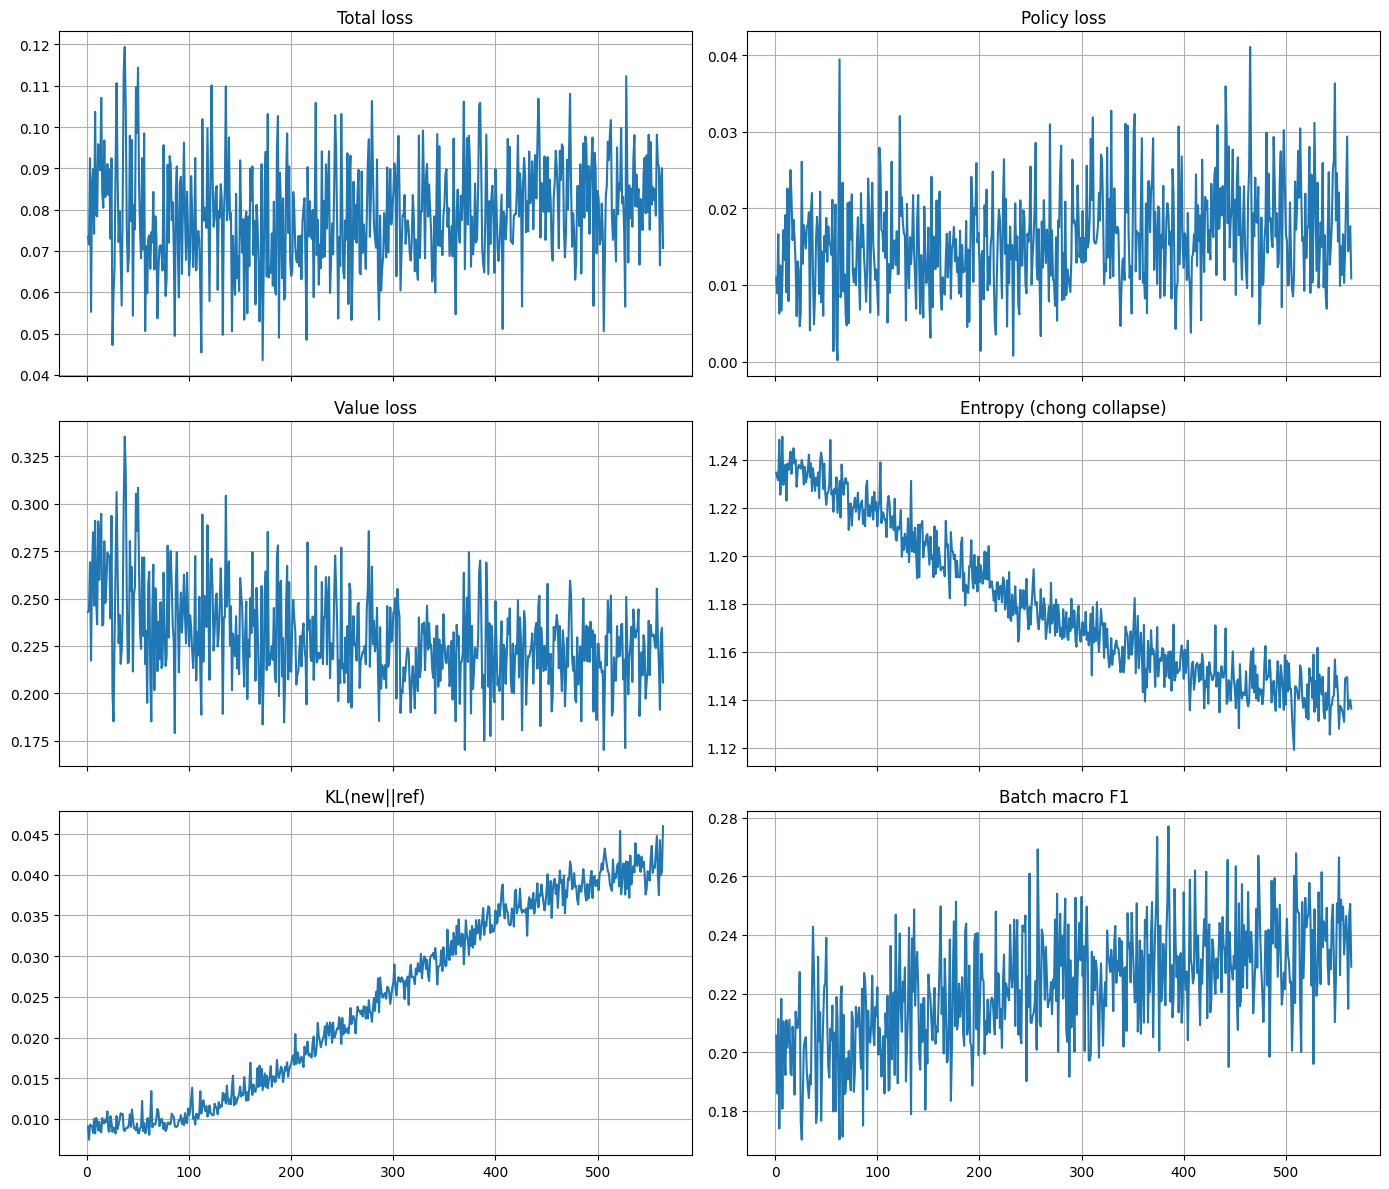

In [12]:
hist = pd.read_csv(SAVE_PATH / "stage3_ppo_history.csv")
fig, axs = plt.subplots(3, 2, figsize=(14,12), sharex=True)
pairs = [("loss","Total loss"),("policy","Policy loss"),("value","Value loss"),
         ("entropy","Entropy (chong collapse)"),("kl","KL(new||ref)"),("batch_f1","Batch macro F1")]
for ax, (col, title) in zip(axs.flatten(), pairs):
    ax.plot(hist["global_step"], hist[col]); ax.set_title(title); ax.grid(True)
plt.tight_layout(); plt.show()

In [13]:
model = PhoBertACSA_ActorCritic().to(DEVICE)
model.load_state_dict(torch.load(SAVE_PATH / "final_ppo_model.bin", map_location=DEVICE))
test_m = evaluate_model(model, test_loader)
print_metrics("Final PPO Test", test_m)
print(classification_report(
    test_m["y_true"].reshape(-1), test_m["y_pred"].reshape(-1),
    labels=list(range(N_POLARITIES)), target_names=LABEL_NAMES, zero_division=0))
with open(SAVE_PATH/"stage3_test_metrics.json","w",encoding="utf-8") as f:
    json.dump({k:float(v) for k,v in test_m.items() if not k.startswith("y_")}, f, indent=2)

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] RobertaModel LOAD REPORT from: vinai/phobert-base
Key                       | Status     |  | 
--------------------------+------------+--+-
lm_head.dense.bias        | UNEXPECTED |  | 
lm_head.bias              | UNEXPECTED |  | 
lm_head.decoder.weight    | UNEXPECTED |  | 
lm_head.dense.weight      | UNEXPECTED |  | 
lm_head.decoder.bias      | UNEXPECTED |  | 
lm_head.layer_norm.weight | UNEXPECTED |  | 
lm_head.layer_norm.bias   | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Final PPO Test | flat_macro_f1: 0.2387 | non_none_macro_f1: 0.4463 | per_aspect_macro_f1: 0.1355 | exact_match: 0.0000
              precision    recall  f1-score   support

        None       0.97      0.39      0.55     17816
    Positive       0.16      0.78      0.26      1806
    Negative       0.08      0.55      0.14       645
     Neutral       0.00      0.00      0.00       133

    accuracy                           0.42     20400
   macro avg       0.30      0.43      0.24     20400
weighted avg       0.86      0.42      0.51     20400

